In [1]:
import os
import mne
import numpy as np
import pandas as pd
import pyecap
from flexNIRs.fnirs_functions import *

import matplotlib.pyplot as plt
import h5py
import mne
import mne.channels
import mne.io.snirf
import mne_nirs.experimental_design
import mne_nirs.statistics

from nilearn.plotting import plot_design_matrix

import mne_nirs
from mne_nirs.channels import get_long_channels, get_short_channels, picks_pair_to_idx
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm
from kernel_functions import *

def get_snirf_file(data_path, hash, snirf_type):
    fileLIST = os.listdir(data_path + r'\\SNIRF')
    snirf_file = [item for item in fileLIST if (hash.lower() in item.lower()) and (snirf_type.lower() in item.lower())][0]
    full_path = data_path + r'\\SNIRF\\' + snirf_file
    return full_path

def fir_filter(data, fs, filter_cutoffs=(0.01, 0.2), transition_width=0.01, numtaps=301,freq_plot=False):
    """Setup Filter"""
    filter_weights = signal.firwin(numtaps, filter_cutoffs, width=transition_width, window='Hamming', pass_zero='bandpass', fs=fs)

    if freq_plot:
        w, h = signal.freqz(filter_weights, worN=fft.next_fast_len(40000, real=True))
        plt.plot((w / np.pi) * (fs / 2), 20 * np.log10(np.abs(h)))
        plt.xlim((0, 2))
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Amplitude (dB)')
        plt.show()

    filt_data = signal.filtfilt(filter_weights, [1], d, axis=1)
    return filt_data


In [2]:
meta_index = 1
snirf_type = 'hb'  #Either 'gates' or 'moments'

path = r'D:\Data\Kernel\20260327_Kernel_QC\\'

metaDF = pd.read_excel(path + 'metadata.xlsx')
#tank = path + r'\\Tanks\\' + metaDF.at[meta_index, 'Tank']
snirf = get_snirf_file(path, metaDF.at[meta_index, 'Kernel Hash'], snirf_type)

#stim = pyecap.Stim(tank)
#stimDF = stim.parameters
#stimDF

raw = mne.io.snirf.read_raw_snirf(snirf)
raw.load_data()

Loading D:\Data\Kernel\20260327_Kernel_QC\SNIRF\study-uwqctesting_sub-kc_desc-bea1c12_HB.snirf
Found jitter of 0.000087% in sample times.
Reading 0 ... 1590  =      0.000 ...   422.940 secs...


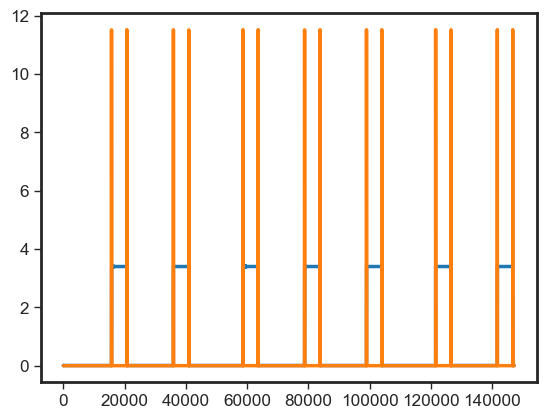

In [3]:
"""Get Sync Signal"""
f = h5py.File(snirf)
sync_signal = f['nirs']['aux22']['dataTimeSeries'][:]
sync_time = f['nirs']['aux22']['time'][:]
stim_idx = np.nonzero(np.diff(np.squeeze(sync_signal))**2 > 1)[0]

idxLIST = []
min_distance = 10
for idx in stim_idx:
    if all(abs(idx - valid_idx) >= min_distance for valid_idx in idxLIST):
        idxLIST.append(idx)
stim_idx = idxLIST

stim_pairs = list(zip(sync_time[stim_idx[::2]], sync_time[stim_idx[1::2]]))
plt.plot(sync_signal)
plt.plot(np.diff(np.squeeze(sync_signal))**2)

In [7]:
"""Get Kernel Data"""
d = raw[:][0]  #Channel data in numpy array
time = raw[:][1] #Time values in numpy array

probe_keys = [
    ("detectorLabels", str),
    ("sourceLabels", str),
    ("sourcePos3D", float),
    ("detectorPos3D", float),
]
with h5py.File(snirf, "r") as file:
    probe_data = {
        key: np.array(file["nirs"]["probe"][key]).astype(dtype)
        for key, dtype in probe_keys
    }
[*probe_data]

idx_sources = np.array([int(ch.split("_")[0][1:]) - 1 for ch in raw.ch_names])
idx_detectors = np.array([int(ch.split("_")[1].split(" ")[0][1:]) - 1 for ch in raw.ch_names])
source_positions = np.array(probe_data["sourcePos3D"])[idx_sources]
detector_positions = np.array(probe_data["detectorPos3D"])[idx_detectors]

mods = [mod.split('M0')[1].split('S0')[0] for mod in np.array(probe_data['sourceLabels'])[idx_sources]]

sds = np.sqrt(np.sum((source_positions - detector_positions) ** 2, axis=1)).astype(int)
if snirf_type == 'hb':
    wavelengths = [(ch.split(' ')[1]) for ch in raw.ch_names]
    d_type = 'hb'
else:
    wavelengths = [int(ch.split(' ')[1]) for ch in raw.ch_names]
    d_type = [ch.split(' ')[2] for ch in raw.ch_names]

"""
Construct DataFrame for Channel Indexing
Columns: Channel name, Source, Detector, SDS, Wavelength, Moment (time bin for gate snirf)
"""
channelDF = pd.DataFrame( {'Channel' : raw.ch_names,
                           'Source' : idx_sources + 1,
                           'Detector' : idx_detectors + 1,
                           'Module' : mods,
                           'SDS' : sds,
                           'Wavelength' : wavelengths,
                           'Classifier' : d_type,}
                          )

In [8]:
"""Apply Filtering"""
fs = raw.info['sfreq']

if int(len(d[0]) / 3) % 2 == 0:
    numtaps = int(len(d[0]) / 3) - 1
else:
    numtaps = int(len(d[0]) / 3)

d_filt = fir_filter(d, fs, filter_cutoffs=(0.01,0.2), transition_width=0.01, numtaps=numtaps, freq_plot=False)

In [47]:
"""Calculate HbT by adding HbO and HbR for each source_detector combination:
Steps:
Get paired indices of S_D combos
Add HbO and HbR for pairs
Generate new numpy array and indexing DF for analysis/plotting
"""
sd_combos = list(dict.fromkeys([ch.split(' ')[0] for ch in raw.ch_names]))
sd_pairs = [list(channelDF.index[channelDF['Channel'].str.contains(combo)]) for combo in sd_combos]

HbT = []
for pair in sd_pairs:
    total = np.sum(d[pair], axis = 0)
    HbT.append(total)
HbT = np.array(HbT)

In [59]:
sd_idx = [idx[0] for idx in sd_pairs]
print(sd_idx)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98]


In [54]:
"""Create indexing dataframe for HbT array"""
sd_idx = [channelDF.index[channelDF['Channel'].str.contains(combo)][0] for combo in sd_combos]

HbT_DF = channelDF.loc[sd_idx]
HbT_DF.reset_index(inplace=True, drop=True)
HbT_DF['Channel'] = HbT_DF['Channel'].str.replace('hbo', 'hbt')
HbT_DF['Wavelength'] = HbT_DF['Wavelength'].str.replace('hbo', 'hbt')

In [57]:
"""Integrate data array and channelDF back into original"""
d = np.vstack((d,HbT))
channelDF = pd.concat([channelDF, HbT_DF])

In [18]:
x = tuple(channelDF.index[channelDF['Channel'].str.contains('S1_D2')])

KeyError: '01 bin1.197e-09'

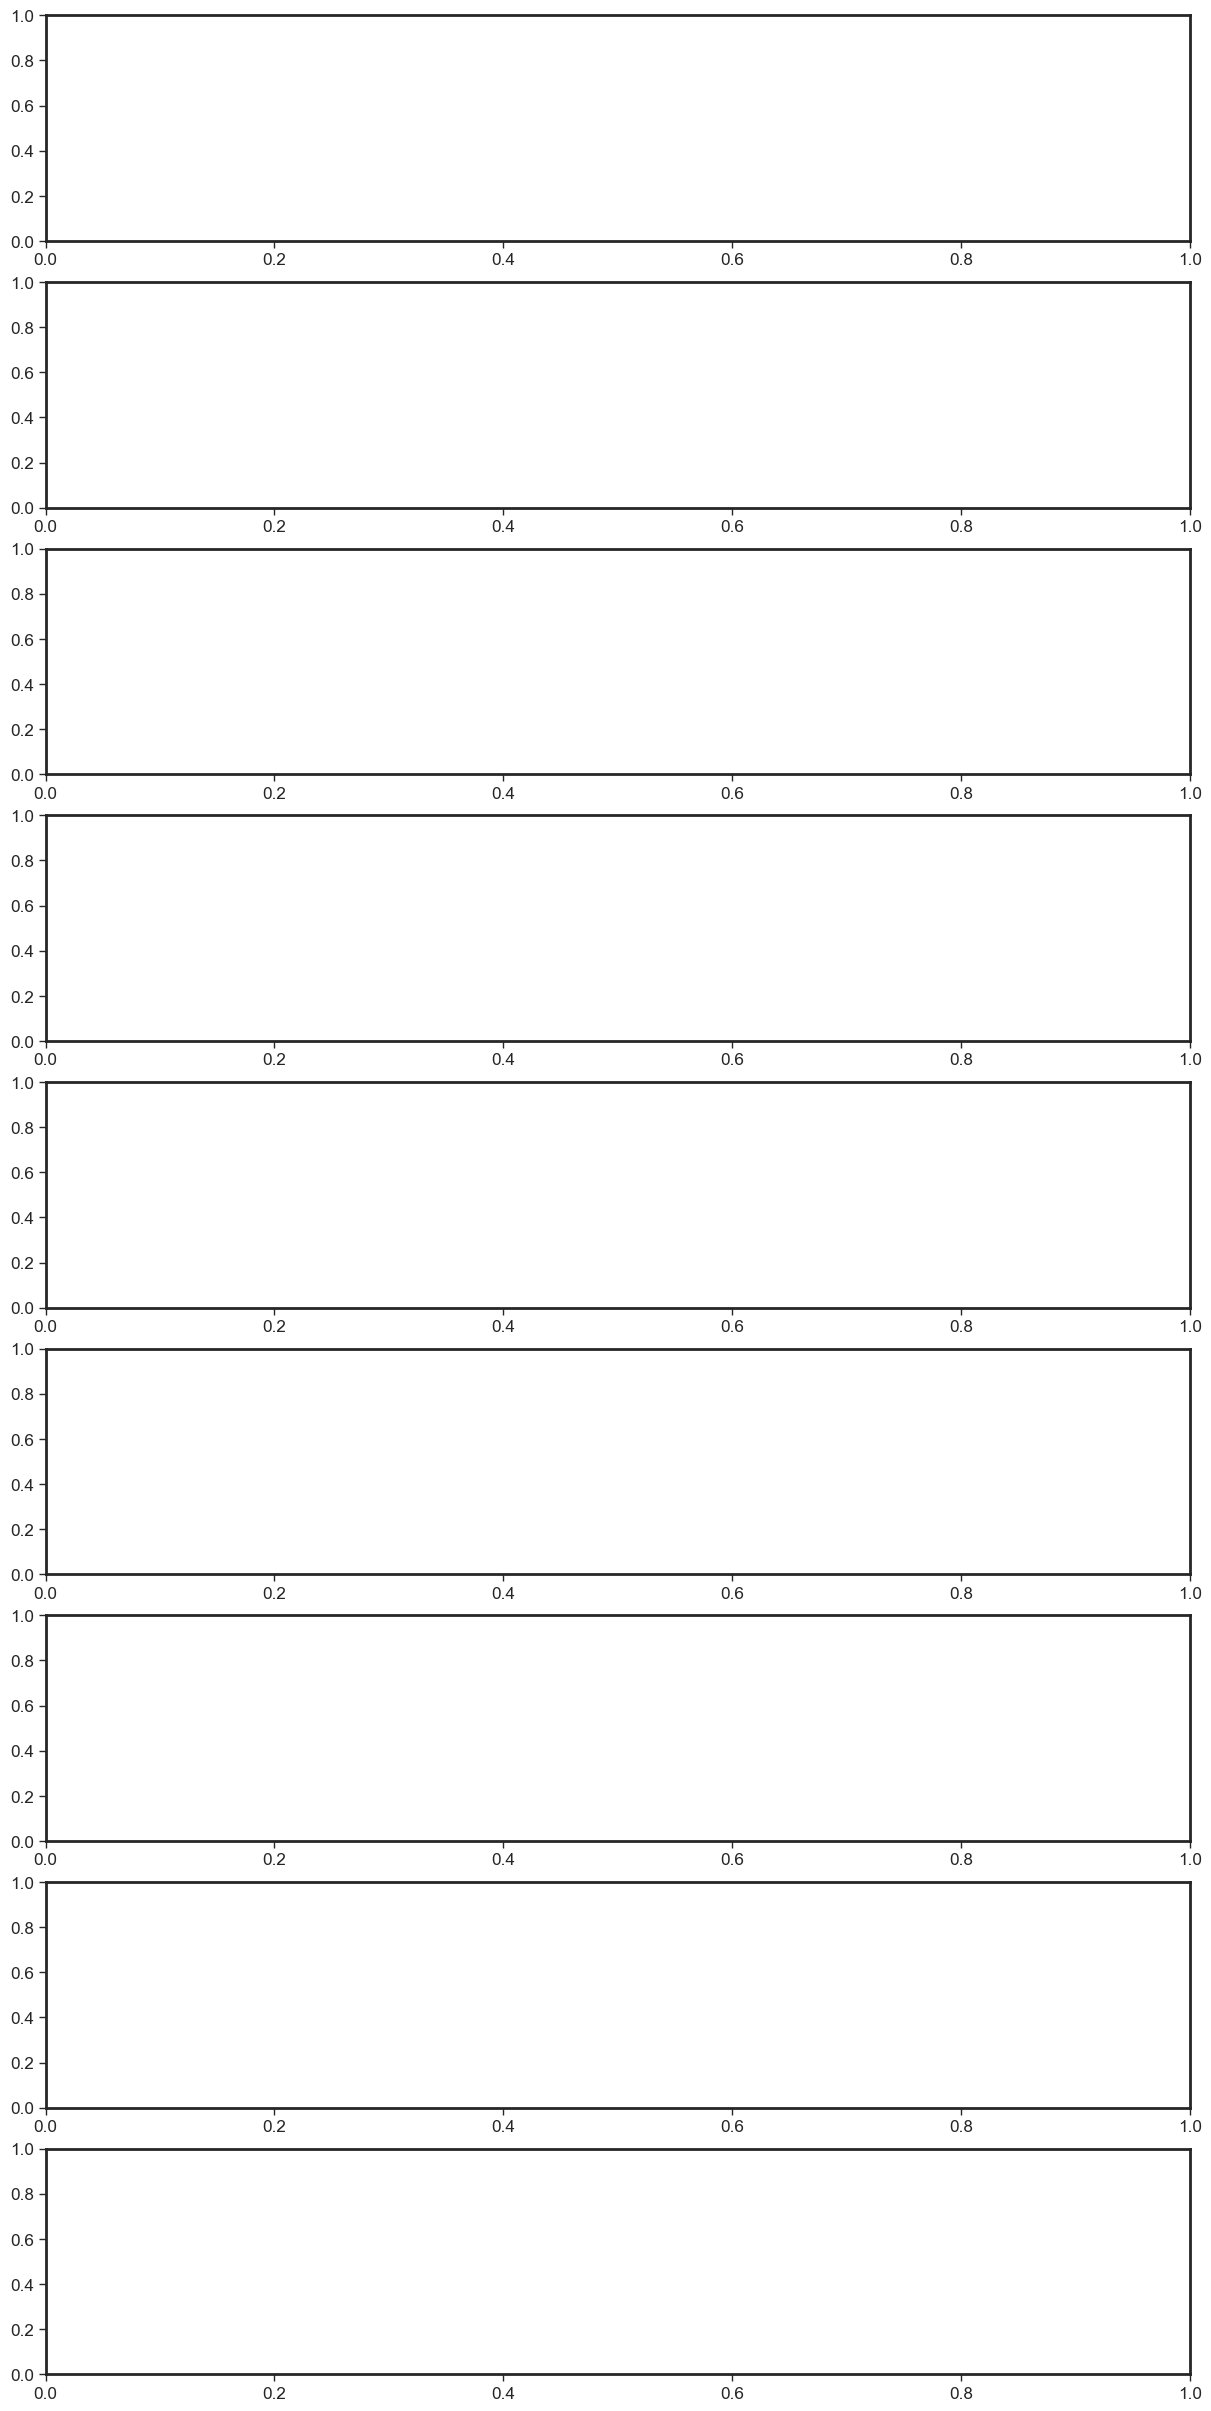

In [264]:
"""Moment Plots
Each column = different moment
Each row = different Module('source')
Data plotted = average of all traces for each SDS
"""
# mosaic = [['01 moment0', '01 moment1', '01 moment2'],
#           ['06 moment0', '06 moment1', '06 moment2'],
#           ['07 moment0', '07 moment1', '07 moment2']
#
# ]

mosaic = [['01 moment0'], ['01 moment1'], ['01 moment2'],
          ['06 moment0'], ['06 moment1'], ['06 moment2'],
          ['07 moment0'], ['07 moment1'], ['07 moment2']

]


fig = plt.figure(figsize=(12,24), layout='constrained')
ax_dict = fig.subplot_mosaic(mosaic, gridspec_kw={'wspace':0, 'hspace':0})
#fig.get_layout_engine().set(w_pad = -10, hspace = -10)

plotDF = channelDF.loc[channelDF['Wavelength'] == 905].copy()

plot_grps = plotDF.groupby(['Module','Wavelength', 'SDS', 'Classifier'])
for name,df in plot_grps:
    data = d_filt[df.index]
    avg = np.mean(data, axis=0)
    axis = name[0] + ' ' + name[3]
    ax_dict[axis].plot(time, avg, label = name[2])
    ax_dict[axis].legend(loc = 'upper right')

for axis in ax_dict:
    [ax_dict[axis].axvspan(xmin,xmax, color = 'gray', alpha =0.25) for xmin,xmax in stim_pairs]

    if '01' in axis:
        ax_dict[axis].set(ylabel = 'PFC SS')
    elif '06' in axis:
        ax_dict[axis].set(ylabel = 'Left SS')
    elif '07' in axis:
        ax_dict[axis].set(ylabel = 'Right SS')

    if 't0' in axis:
        ax_dict[axis].set(title = 'Moment 0')
    elif 't1' in axis:
        ax_dict[axis].set(title = 'Moment 2')
    elif 't2' in axis:
        ax_dict[axis].set(title = 'Moment 3')

ax_dict['01 moment0'].set(title = 'Moment 0', ylabel = 'PFC')
ax_dict['01 moment1'].set(title = 'Moment 1', ylabel = 'PFC')
ax_dict['01 moment2'].set(title = 'Moment 2', ylabel = 'PFC')
ax_dict['06 moment0'].set(ylabel = 'Left SS')
ax_dict['07 moment0'].set(ylabel = 'Right SS')


In [265]:
"""Gates Plot
Bin by SDS
Plot traces by time bin
3X plots, one for each SDS
6X to account for diff wavelengths?
"""

mosaic = [['01 753'],
          ['01 905'],
          ['06 753'],
          ['06 905'],
          ['07 753'],
          ['07 905']
]

# fig = plt.figure(figsize=(12,24), layout='constrained')
#ax_dict = fig.subplot_mosaic(mosaic, gridspec_kw={'wspace':0, 'hspace':0})
#fig.get_layout_engine().set(w_pad = -10, hspace = -10)

plotDF = channelDF.copy()

plot_grps = plotDF.groupby(['Module','Wavelength', 'SDS', 'Classifier'])
# for name,df in plot_grps:
#     """Within 'name', idx0 = Module, idx1 = wavelength, idx2 = SDS, idx3 = time gate"""
#     data = d_filt[df.index]
#     avg = np.mean(data, axis=0)
#     axis = name[0] + ' ' + str(name[1])
#     ax_dict[axis].plot(time, avg, label = name[3])
#     ax_dict[axis].legend(loc = 'upper right')

# for axis in ax_dict:
#     [ax_dict[axis].axvspan(xmin,xmax, color = 'gray', alpha =0.25) for xmin,xmax in stim_pairs]
#
#     if '01' in axis:
#         ax_dict[axis].set(ylabel = 'PFC SS')
#     elif '06' in axis:
#         ax_dict[axis].set(ylabel = 'Left SS')
#     elif '07' in axis:
#         ax_dict[axis].set(ylabel = 'Right SS')
#
#     if 't0' in axis:
#         ax_dict[axis].set(title = 'Moment 0')
#     elif 't1' in axis:
#         ax_dict[axis].set(title = 'Moment 2')
#     elif 't2' in axis:
#         ax_dict[axis].set(title = 'Moment 3')
#
# ax_dict['01 moment0'].set(title = 'Moment 0', ylabel = 'PFC')
# ax_dict['01 moment1'].set(title = 'Moment 1', ylabel = 'PFC')
# ax_dict['01 moment2'].set(title = 'Moment 2', ylabel = 'PFC')
# ax_dict['06 moment0'].set(ylabel = 'Left SS')
# ax_dict['07 moment0'].set(ylabel = 'Right SS')


In [266]:
plot_grps.groups[('07', 905, 26)]

KeyError: ('07', 905, 26)

In [267]:
plot_grps = plotDF.groupby(['Module','Wavelength', 'SDS'])

In [268]:
sub_df = plotDF.loc[plot_grps.groups[('01', 753, 26)]].copy()

gates = np.array(sub_df['Classifier'].unique())
filt_df =sub_df[ sub_df['Classifier'].isin(gates[[0,15]])]
#gates[[0,4,9,14,19,24]]

#fig, ax = plt.subplots()
fig = go.Figure()
gate_grp = filt_df.groupby('Classifier')
for gate, df in gate_grp:
    print(gate)
    data = d_filt[df.index]
    avg = np.nanmean(data, axis=0)
    avg_nrm = avg / np.max(avg)
    fig.add_trace(go.Scatter(x = time, y = avg_nrm, name = gate))

[fig.add_vrect(xmin,xmax, fillcolor = 'red', opacity =0.25) for xmin,xmax in stim_pairs]
fig.show()

bin1.33e-10
bin4.123e-09


In [269]:
gates[0]

'bin1.33e-10'

In [270]:
5.19e-09 * 3e8

1.557

In [271]:
1.33e-10 * 3e8

0.039900000000000005

In [275]:
2.66e-10 * 1e12

266.0

In [273]:
sub_df = plotDF.loc[plot_grps.groups[('06', 753, 26)]].copy()

gates = np.array(sub_df['Classifier'].unique())
filt_df =sub_df[ sub_df['Classifier'].isin(gates[[0,5]])]
#gates[[0,4,9,14,19,24]]

#fig, ax = plt.subplots()
fig = go.Figure()
gate_grp = filt_df.groupby('Classifier')
for gate, df in gate_grp:
    print(gate)
    data = d_filt[df.index]
    avg = np.nanmean(data, axis=0)
    avg_nrm = avg / np.max(avg)
    fig.add_trace(go.Scatter(x = time, y = avg_nrm, name = gate))

[fig.add_vrect(xmin,xmax, fillcolor = 'red', opacity =0.25) for xmin,xmax in stim_pairs]
fig.show()

bin1.33e-10
bin1.463e-09


In [259]:
sub_df = plotDF.loc[plot_grps.groups[('06', 753, 8)]].copy()

gates = np.array(sub_df['Classifier'].unique())
filt_df =sub_df[ sub_df['Classifier'].isin(gates[[0,8]])]
#gates[[0,4,9,14,19,24]]

#fig, ax = plt.subplots()
fig = go.Figure()
gate_grp = filt_df.groupby('Classifier')
for gate, df in gate_grp:
    print(gate)
    data = d_filt[df.index]
    avg = np.nanmean(data, axis=0)
    avg_nrm = avg / np.max(avg)
    fig.add_trace(go.Scatter(x = time, y = avg_nrm, name = gate))

[fig.add_vrect(xmin,xmax, fillcolor = 'red', opacity =0.25) for xmin,xmax in stim_pairs]
fig.show()

bin1.33e-10
bin2.261e-09


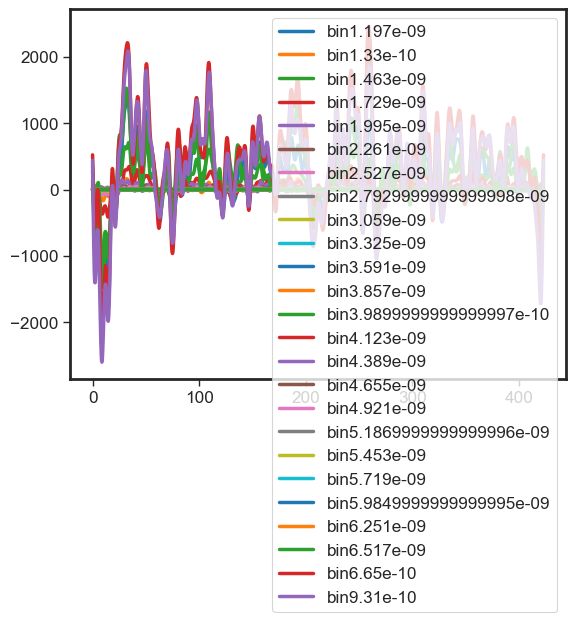

In [234]:
fig, ax = plt.subplots()
gate_grp = sub_df.groupby('Classifier')
for gate, df in gate_grp:q
    data = d_filt[df.index]
    avg = np.mean(data, axis=0)
    ax.plot(time,avg, label = gate)
    ax.legend()

In [154]:
|df3 = channelDF.loc[channelDF['Module'] == '01'].copy()

In [155]:
df3['Classifier'] = channelDF['Classifier'].str.replace('bin','').astype(float)
sortDF = df3.sort_values(by='Classifier')

In [246]:
gates = np.array(df3['Classifier'].unique())
gates[[0,4,9,14,19,24]]

array([1.330e-10, 1.197e-09, 2.527e-09, 3.857e-09, 5.187e-09, 6.517e-09])

In [247]:
np.diff(gates)

array([2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10,
       2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10,
       2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10,
       2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10, 2.66e-10])

In [157]:
filt_df = df3[ df3['Classifier'].isin(gates[[0,14,24]])]

In [158]:
filt_df['Classifier'].unique()

array([1.330e-10, 3.857e-09, 6.517e-09])

In [159]:
#fig, ax = plt.subplots()
fig = go.Figure()
gate_grp = filt_df.groupby('Classifier')
for gate, df in gate_grp:
    data = d_filt[df.index]
    avg = np.mean(data, axis=0)
    avg_nrm = avg / np.max(avg)
    fig.add_trace(go.Scatter(x = time, y = avg_nrm, name = gate))

[fig.add_vrect(xmin,xmax, fillcolor = 'red', opacity =0.25) for xmin,xmax in stim_pairs]
fig.show()

C:\Users\kpcheng\AppData\Local\Temp\ipykernel_26736\501184008.py:7: RuntimeWarning:

invalid value encountered in divide



In [ ]:
"""Setup Filter"""
fs = raw.info['sfreq']
filter_cutoffs=(0.01, 0.2)
transition_width=0.01

if int(len(d[0]) / 3) % 2 == 0:
    numtaps = int(len(d[0]) / 3) - 1
else:
    numtaps = int(len(d[0]) / 3)

filter_weights = signal.firwin(numtaps, filter_cutoffs, width=transition_width, window='Hamming', pass_zero='bandpass', fs=fs)
filt_data = signal.filtfilt(filter_weights, [1], d, axis=1, padtype = 'odd')

w, h = signal.freqz(filter_weights, worN=fft.next_fast_len(40000, real=True))
plt.plot((w / np.pi) * (fs / 2), 20 * np.log10(np.abs(h)))
plt.xlim((0, 2))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')
plt.show()

In [ ]:
probe_keys = [
    ("detectorLabels", str),
    ("sourceLabels", str),
    ("sourcePos3D", float),
    ("detectorPos3D", float),
]
with h5py.File(snirf, "r") as file:
    probe_data = {
        key: np.array(file["nirs"]["probe"][key]).astype(dtype)
        for key, dtype in probe_keys
    }
[*probe_data]

In [ ]:
"""Get the stim-relevant annotation from list of event types"""
with h5py.File(snirf, "r") as file:
  ctr = 1
  while (stim:=f"stim{ctr}") in file["nirs"]:
    print(stim, np.array(file["nirs"][stim]["name"]))
    ctr+=1

with h5py.File(snirf, "r") as file:
  df_start_block = pd.DataFrame(data = np.array(file["nirs"]["stim1"]["data"]), columns=[col.decode('UTF-8') for col in file["nirs"]["stim1"]["dataLabels"]])
df_start_block

In [ ]:
"""Write new annotations"""
events, _ = mne.events_from_annotations(raw, {"StartBreathHold": 1})
event_id = {"Stim": 2, "Breathing": 1}
#events[df_start_block["BlockType.Left"] == 1., 2] = event_id["Tapping/Left"]
#events[df_start_block["BlockType.Right"] == 1., 2] = event_id["Tapping/Right"]
events

In [ ]:
#event_id = {'StartBreathHold' : 2}
mne.viz.plot_events(events, sfreq=raw.info["sfreq"]);

In [ ]:
tmin, tmax = -5, 30
epochs = mne.Epochs(
    raw,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    proj=True,
    baseline=(None, 0),
    preload=True,
    detrend=None,
    verbose=True,
)

In [ ]:
idx_sources = np.array([int(ch.split("_")[0][1:]) - 1 for ch in epochs.info["ch_names"]])
idx_detectors = np.array([int(ch.split("_")[1].split(" ")[0][1:]) - 1 for ch in epochs.info["ch_names"]])
source_positions = np.array(probe_data["sourcePos3D"])[idx_sources]
detector_positions = np.array(probe_data["detectorPos3D"])[idx_detectors]
sds = np.sqrt(np.sum((source_positions - detector_positions) ** 2, axis=1))

In [ ]:
"""Limits channels to include based on conditional"""
#idx_channels = np.flatnonzero((sds > 15) & (sds < 30))
idx_channels = np.flatnonzero((sds > 40))
stim_evoked = epochs.average(picks=idx_channels)

In [ ]:
probe_data['sourceLabels']

In [ ]:
idx_sources = np.array([int(ch.split("_")[0][1:]) - 1 for ch in stim_evoked.info["ch_names"]]) #Generates array where value is the source # for each data stream
is_selected_hbo = np.array([ch.endswith("0") for ch in stim_evoked.info["ch_names"]]) #Generates boolean mask based on conditional to select which data streams to plot

# MODULE 0 is centered, MODULE 1 is left, MODULE 2 is right side -- Why do they limit to single source though?
left = is_selected_hbo & (idx_sources== np.flatnonzero(np.array(probe_data["sourceLabels"]) == "M001S01")[0])
center = is_selected_hbo & (idx_sources== np.flatnonzero(np.array(probe_data["sourceLabels"]) == "M000S01")[0])
right = is_selected_hbo & (idx_sources== np.flatnonzero(np.array(probe_data["sourceLabels"]) == "M002S01")[0])

# average all channels coming from source 20 or 21 formed with detectors between 15-30mm from the source
combined = mne.channels.combine_channels(stim_evoked, {"left": np.flatnonzero(left), "right": np.flatnonzero(right), 'center': np.flatnonzero(center)})

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
mne.viz.plot_compare_evokeds(combined, picks = ['left'], legend='upper left', axes=ax, show=False)
mne.viz.plot_compare_evokeds(combined, picks = ['right'], legend='upper left', axes=ax, show=False)
mne.viz.plot_compare_evokeds(combined, picks = ['center'], legend='upper left', axes=ax, show=False)
plt.show()

In [ ]:
stim_evoked.plot()

In [ ]:
channels = raw.ch_names

In [ ]:
bins = [bin.split('bin')[1] for bin in channels]

In [ ]:
bin_times = np.sort(np.array(list(set(bins))))